In [20]:
%matplotlib widget


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

project_root = "/home/tang584/scripts/linux_resource_detect/perf_analysis"

pattern_configs = {
    "montage":{
        "task_order_list" : f"{project_root}/montage/montage_script_order.json",
        "csv_file_path" : f'{project_root}/fastflow_plots/montage_s8_tr_estimated_fixed.csv',
        "plot_file_name" : 'montage_3d_relationship_files.pdf',
        "file_group_patterns" : [
            "region-oversized.hdr",
            "poss2ukstu_blue_.*\\.fits",
            "pposs2ukstu_blue_.*\\.fits",
            "pposs2ukstu_blue_.*\\_area.fits",
            "1-diff.*\\.txt",
            "1-fit.*\\.txt",
            "1-fits.tbl",
            "1-images.tbl",
            "1-corrections.tbl",
            "1-projected.tbl",
            "cposs2ukstu_blue_.*\\.fits",
            "cposs2ukstu_blue_.*\\_area.fits",
            "1-corrected.tbl",
            "1-updated-corrected.tbl",
            "1-updated-corrected.tbl",
            "region.hdr",
            "1-mosaic.fits",
            "1-mosaic.png"
        ],
        "result_path": f"./montage_plots"
    }
}

# Define file grouping file_group_patterns



def shorten_task_name(name):
    parts = name.split("_")
    # print(f"Original parts: {parts}")
    shortened = [p[:10] for i, p in enumerate(parts) if i % 2 == 0 or i == len(parts) - 1]
    # print(f"Shortened: {shortened}")
    return "_".join(shortened)

In [2]:

# Read CSV file
# csv_file_path = '{project_root}/fastflow_plots/par_9000_1n_pfs_ps300_fixed.csv'
# plot_file_name = '9000_3d_relationship_files.pdf'

# csv_file_path = '{project_root}/fastflow_plots/summer_sam_4n_pfs_s9_tr_estimated.csv'
# plot_file_name = 'pyflex_3d_relationship_files.pdf'

CURR_WF = "montage" # pyflex, ddmd, 1kgenome

csv_file_path = pattern_configs[CURR_WF]["csv_file_path"]
plot_file_name = pattern_configs[CURR_WF]["plot_file_name"]
file_group_patterns = pattern_configs[CURR_WF]["file_group_patterns"]
task_order_file = pattern_configs[CURR_WF]["task_order_list"]
extension_grouping = pattern_configs[CURR_WF].get("extension_grouping", False)
result_path = pattern_configs[CURR_WF].get("result_path", "./result_plots")

df = pd.read_csv(csv_file_path)


In [3]:
df.size, df.shape, df.columns, df['operation'].unique()

# Replace with shortened task name in all taskName columns
short_taskName_dict = {
    "mProject": "mPro",
    "mDiffFit": "mDiffF",
    "mConcatFit": "mConF",
    "mBgModel": "mBgM",
    "mBackground": "mBg",
    "mImgtbl": "mImg",
    "mAdd": "mAdd",
    "mViewer": "mView",
}

# Replace task names in the DataFrame
df['taskName'] = df['taskName'].replace(short_taskName_dict)
# Replace task names in the DataFrame
df['prevTask'] = df['prevTask'].replace(short_taskName_dict)


/tmp/ipykernel_1439218/2471573912.py:69: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


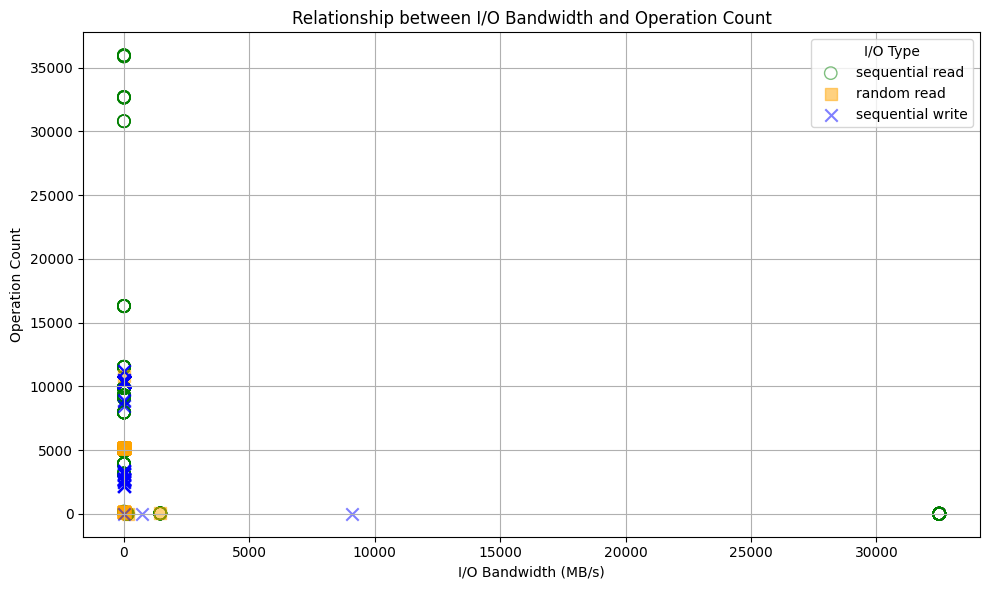

In [4]:
# # Add new columns for colors and labels based on the 'operation' column
# df['color'] = df['operation'].map({0: 'blue', 1: 'red'})
# df['label'] = df['operation'].map({0: 'write', 1: 'read'})
# df['marker'] = df['operation'].map({0: 'x', 1: 'o'})  # 'o' for circle, 's' for square

# # 2D plot: Relationship between aggregateFilesizeMB and totalTime
# plt.figure(figsize=(10, 6))

# for label in df['label'].unique():
#     subset = df[df['label'] == label]
#     marker = subset['marker'].iloc[0]
#     facecolor = 'none' if marker == 'o' else subset['color'].iloc[0]
#     plt.scatter(subset['trMiB'], subset['opCount'], 
#                 label=label, 
#                 edgecolor=subset['color'].iloc[0],  # Edge color for circle markers
#                 facecolors=facecolor,  # Only the circle markers will be hollow
#                 marker=marker,
#                 s=80,
#                 alpha=0.5)

# plt.title('Relationship between Transfer Size and Total Time')
# plt.xlabel('I/O Bandwidth (MB/s)')
# # plt.xlabel('Data size (MB)')
# plt.ylabel('Operation count')
# plt.grid(True)
# plt.legend(title="Operation")
# plt.show()

# Define mapping of operation and randomness to I/O type
def map_io_type(row):
    if row['operation'] == 0 and row['randomOffset'] == 0:
        return 'sequential write'
    elif row['operation'] == 0 and row['randomOffset'] == 1:
        return 'random write'
    elif row['operation'] == 1 and row['randomOffset'] == 0:
        return 'sequential read'
    elif row['operation'] == 1 and row['randomOffset'] == 1:
        return 'random read'
    else:
        return 'unknown'

# Apply the mapping
df['io_type'] = df.apply(map_io_type, axis=1)

# Assign colors and markers to each I/O type
io_color_map = {
    'sequential write': 'blue',
    'random write': 'purple',
    'sequential read': 'green',
    'random read': 'orange',
}
io_marker_map = {
    'sequential write': 'x',
    'random write': 'D',
    'sequential read': 'o',
    'random read': 's',
}

df['color'] = df['io_type'].map(io_color_map)
df['marker'] = df['io_type'].map(io_marker_map)

# 2D plot: Relationship between I/O Bandwidth and Operation Count
plt.figure(figsize=(10, 6))

for io_type in df['io_type'].unique():
    subset = df[df['io_type'] == io_type]
    marker = subset['marker'].iloc[0]
    facecolor = 'none' if marker == 'o' else subset['color'].iloc[0]
    plt.scatter(
        subset['trMiB'], 
        subset['opCount'], 
        label=io_type, 
        edgecolor=subset['color'].iloc[0], 
        facecolors=facecolor,
        marker=marker,
        s=80,
        alpha=0.5
    )

plt.title('Relationship between I/O Bandwidth and Operation Count')
plt.xlabel('I/O Bandwidth (MB/s)')
plt.ylabel('Operation Count')
plt.grid(True)
plt.legend(title="I/O Type")
plt.tight_layout()
plt.show()


/tmp/ipykernel_1439218/3671769063.py:12: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


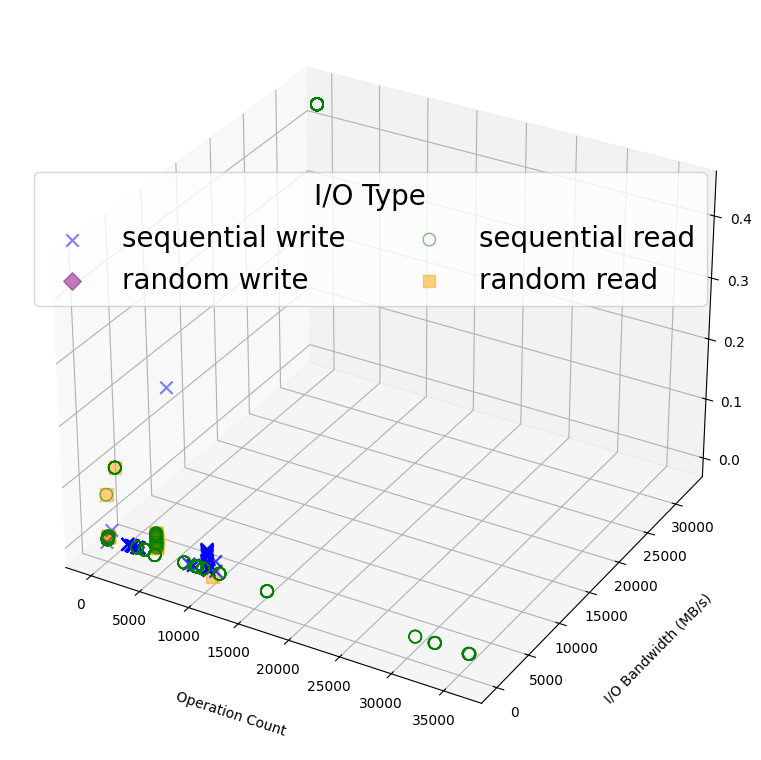

In [5]:
# 3D plot: Relationship between aggregateFilesizeMB, opCount, and trMiB
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data for present I/O types
for io_type, color in io_color_map.items():
    subset = df[df['io_type'] == io_type]
    marker = io_marker_map[io_type]
    facecolor = 'none' if marker == 'o' else color

    if not subset.empty:
        ax.scatter(
            subset['opCount'],
            subset['trMiB'],
            subset['aggregateFilesizeMB'],
            label=io_type,
            edgecolor=color,
            facecolors=facecolor,
            marker=marker,
            s=80,
            alpha=0.5
        )
    else:
        # Add a dummy scatter for missing data to include in legend
        ax.scatter([], [], [], 
                   label=io_type,
                   edgecolor=color,
                   facecolors='none' if marker == 'o' else color,
                   marker=marker,
                   s=80,
                   alpha=0.5)

# Font size settings
plt.rc('font', size=20)
plt.rc('axes', titlesize=24)
plt.rc('axes', labelsize=24)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=20)

ax.set_xlabel('Operation Count', labelpad=20)
ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=20)
ax.set_zlabel('Flow Size (MB)', labelpad=20)

ax.legend(title="I/O Type", loc='best', bbox_to_anchor=(0.16, 0.8, 0.8, 0.0), ncol=2)

plt.tight_layout()
plt.show()
fig.savefig(f"{result_path}/op_{plot_file_name}")

/tmp/ipykernel_1439218/3660275674.py:12: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


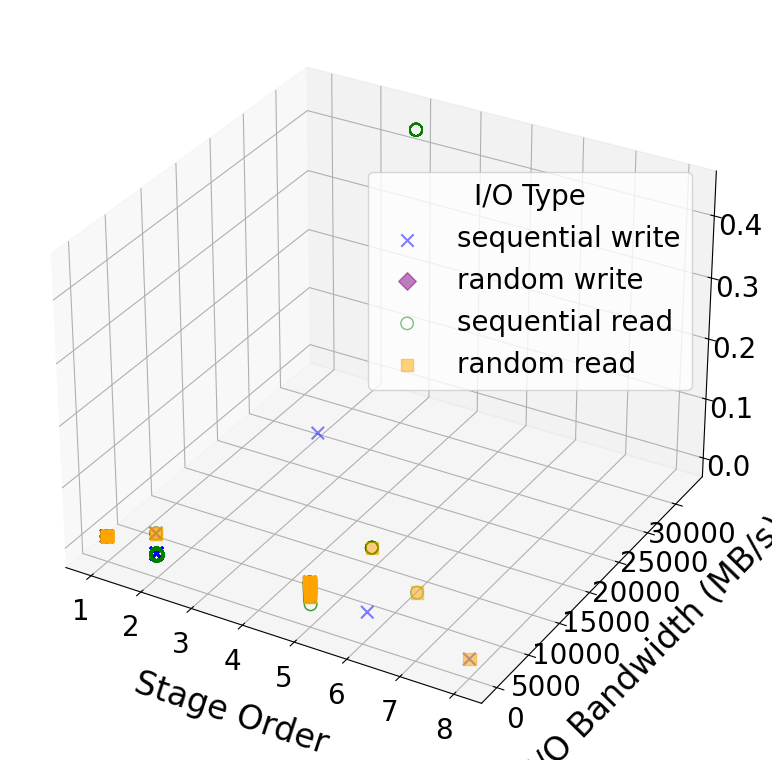

In [6]:
# 3D plot: Relationship between aggregateFilesizeMB, stageOrder, and trMiB
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot for each defined I/O type, whether or not data exists
for io_type, color in io_color_map.items():
    subset = df[df['io_type'] == io_type]
    marker = io_marker_map[io_type]
    facecolor = 'none' if marker == 'o' else color

    if not subset.empty:
        ax.scatter(
            subset['stageOrder'],
            subset['trMiB'],
            subset['aggregateFilesizeMB'],
            label=io_type,
            edgecolor=color,
            facecolors=facecolor,
            marker=marker,
            s=80,
            alpha=0.5
        )
    else:
        # Dummy point for legend
        ax.scatter([], [], [],
                   label=io_type,
                   edgecolor=color,
                   facecolors=facecolor,
                   marker=marker,
                   s=80,
                   alpha=0.5)

# Font size settings
plt.rc('font', size=20)
plt.rc('axes', titlesize=24)
plt.rc('axes', labelsize=24)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.rc('legend', fontsize=20)

# Switched axes
ax.set_xlabel('Stage Order', labelpad=20)
ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=20)
ax.set_zlabel('Flow Size (MB)', labelpad=20)

ax.legend(title="I/O Type", loc='best', bbox_to_anchor=(0.14, 0.8, 0.8, 0.0))

plt.tight_layout()
plt.show()
fig.savefig(f"{result_path}/stage_{plot_file_name}")


{'mProject': {'stage_order': 1, 'parallelism': 16, 'num_tasks': 16, 'predecessors': {'initial_data': {'inputs': ['region-oversized.hdr', 'poss2ukstu_blue_\\d{3}_\\d{3}.fits']}}, 'outputs': ['pposs2ukstu_blue_\\d{3}_\\d{3}.fits', 'pposs2ukstu_blue_\\d{3}_\\d{3}_area.fits', '1-diff.\\d{6}.\\d{6}.txt']}, 'mDiffFit': {'stage_order': 2, 'parallelism': 120, 'num_tasks': 120, 'predecessors': {'initial_data': {'inputs': ['region-oversized.hdr']}, 'mProject': {'inputs': ['pposs2ukstu_blue_\\d{3}_\\d{3}.fits', 'pposs2ukstu_blue_\\d{3}_\\d{3}_area.fits', '1-diff.\\d{6}.\\d{6}.txt']}}, 'outputs': ['1-fit.\\d{6}.\\d{6}.txt']}, 'mConcatFit': {'stage_order': 3, 'parallelism': 1, 'num_tasks': 1, 'predecessors': {'mDiffFit': {'inputs': ['1-fit.\\d{6}.\\d{6}.txt']}}, 'outputs': ['1-fits.tbl']}, 'mBgModel': {'stage_order': 4, 'parallelism': 1, 'num_tasks': 1, 'predecessors': {'mConcatFit': {'inputs': ['1-fits.tbl']}, 'initial_data': {'inputs': ['1-images.tbl']}}, 'outputs': ['1-corrections.tbl']}, 'mBack

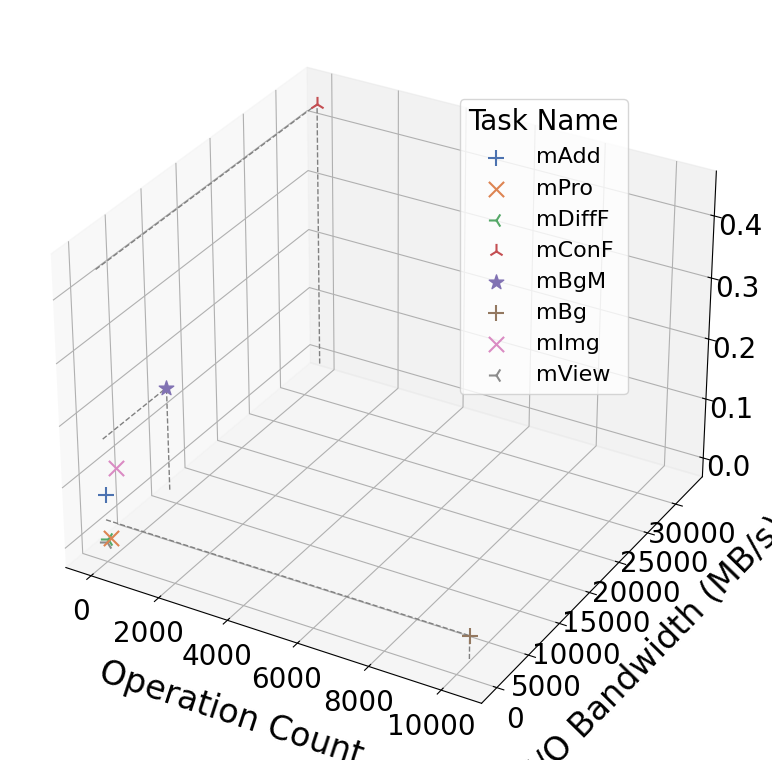

In [7]:
import seaborn as sns
import json


# Load task ordering json file
task_order_dict = {}
with open(task_order_file) as f:
    task_order_dict = json.load(f)

print(task_order_dict)

# Ensure tasks are ordered based on task_order_dict
unique_tasks = sorted(
    df['taskName'].unique(), 
    key=lambda t: task_order_dict.get(t, {}).get('stage_order', float('inf'))
)

# Debugging output
print(f"Unique tasks: {unique_tasks}")  
if not unique_tasks:
    print("No tasks found, skipping plotting.")
    exit()

num_tasks = len(unique_tasks)

# Define color palette and markers
palette = sns.color_palette("deep", num_tasks)
# markers = ['+', 'x', '3', '2', '*', '^', 's', 'o', 'D', 'p', 'h']

# Split tasks into groups of 5
task_group_count = 10
task_groups = [unique_tasks[i:i+task_group_count] for i in range(0, num_tasks, task_group_count)]

for group_idx, task_group in enumerate(task_groups):


    # Filter out empty groups
    valid_tasks = [task for task in task_group if task in df['taskName'].values]
    print(f"Group {group_idx+1}: {valid_tasks}")
    if not valid_tasks:
        print(f"Skipping empty group {group_idx+1}")
        continue

    # 3D plot: Relationship between aggregateFilesizeMB, totalTime, and trMiB
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    x = df['trMiB']
    y = df['opCount']
    z = df['aggregateFilesizeMB']
    markers = ['+', 'x', '3', '2', '*']  # Add more markers as needed

    # Generate color and marker maps for current group
    color_map = {task: palette[i % len(palette)] for i, task in enumerate(valid_tasks)}
    marker_map = {task: markers[i % len(markers)] for i, task in enumerate(valid_tasks)}

    df['color'] = df['taskName'].map(lambda task: color_map.get(task, 'black'))  # Black if not found
    df['marker'] = df['taskName'].map(lambda task: marker_map.get(task, 'o'))  # 'o' if not found

    for task in valid_tasks:
        subset = df[df['taskName'] == task]
        if subset.empty:
            print(f"Skipping task '{task}' (no data)")
            continue
        
        opCount = subset['opCount'].iloc[0]
        trMiB = subset['trMiB'].iloc[0]
        filesize = subset['aggregateFilesizeMB'].iloc[0]

        ax.scatter(opCount, trMiB, filesize, 
                   label=shorten_task_name(task), 
                   color=color_map[task], 
                   marker=marker_map[task],
                   s=120)
        if "mConF" in task or "mBg" in task:
            ax.plot([opCount, opCount], [trMiB, trMiB], [0, filesize], linestyle='dashed', color='gray', linewidth=1)
            ax.plot([opCount, opCount], [0, trMiB], [filesize, filesize], linestyle='dashed', color='gray', linewidth=1)
            ax.plot([0, opCount], [trMiB, trMiB], [filesize, filesize], linestyle='dashed', color='gray', linewidth=1)

    # Set labels and title
    plt.rc('font', size=20)
    plt.rc('axes', titlesize=24)
    plt.rc('axes', labelsize=24)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.rc('legend', fontsize=16)
    
    
    ax.set_xlabel('Operation Count', labelpad=20)
    ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=20)
    ax.set_zlabel('Flow Size (MB)', labelpad=20)

    ax.legend(title="Task Name", loc="right", bbox_to_anchor=(0.05, 0.68, 0.8, 0.0)) # (0, 0.83, 0.8, 0.0) (0, 0.6, 1.3, 0.0)
    fig.tight_layout()
    # plt.figure(constrained_layout=True)

    plt.show()
    fig.savefig(f'{result_path}/taskColor_group{group_idx+1}_'+plot_file_name)


In [8]:
import re
import os

# Compile regex patterns once
compiled_patterns = [(pattern, re.compile(pattern)) for pattern in file_group_patterns]

def extract_group(filename):
    for pattern_str, pattern in compiled_patterns:
        if pattern.search(filename):
            return pattern_str.replace("\\", "")  # Remove backslashes
    return "group_other"


# Apply to dataframe
df["file_group"] = df["fileName"].apply(extract_group)

# Check results
print("Unique file groups:")
print(df["file_group"].value_counts())

def padded_range(series, pad_ratio=0.05):
    """Return min and max with padding based on data range."""
    min_val = series.min()
    max_val = series.max()
    pad = (max_val - min_val) * pad_ratio
    return min_val - pad, max_val + pad

Unique file groups:
file_group
poss2ukstu_blue_.*.fits    612
region-oversized.hdr       136
group_other                129
1-fit.*.txt                120
1-corrections.tbl           17
1-projected.tbl             16
1-updated-corrected.tbl      3
region.hdr                   1
1-mosaic.png                 1
1-mosaic.fits                1
Name: count, dtype: int64


Unique groups [10]: ['region-oversized.hdr' 'poss2ukstu_blue_.*.fits' 'group_other'
 '1-corrections.tbl' '1-projected.tbl' '1-fit.*.txt'
 '1-updated-corrected.tbl' 'region.hdr' '1-mosaic.png' '1-mosaic.fits']


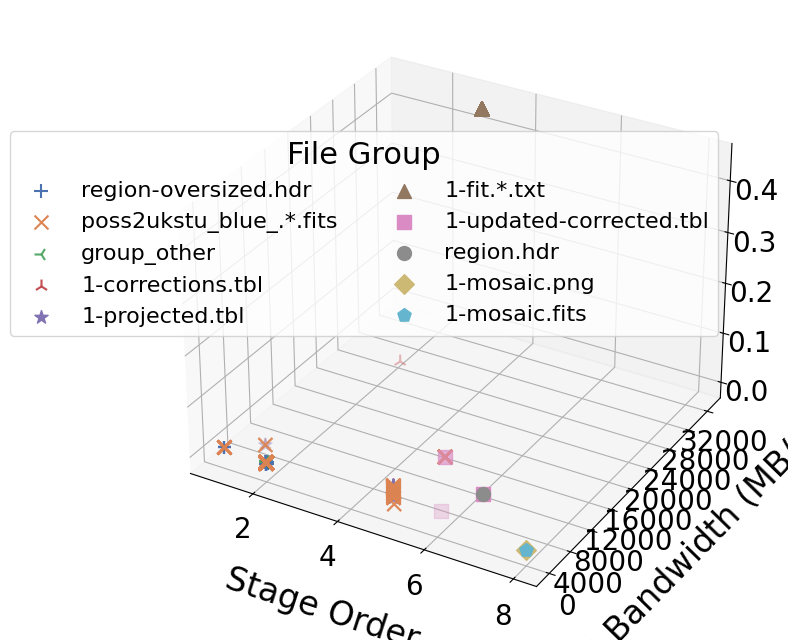

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Generate a color palette
unique_groups = df["file_group"].unique()
print(f"Unique groups [{len(unique_groups)}]: {unique_groups}")

num_groups = len(unique_groups)

# Define color palette and markers
# Define color palette and markers
palette = sns.color_palette("deep", num_groups)
markers = ['+', 'x', '3', '2', '*', '^', 's', 'o', 'D', 'p', 'h']

# Groups to exclude for 1000 genome
exclude_groups = ['AFR', 'EAS', 'SAS', 'ALL', 'EUR', 'GBR', 'AMR']
# Remove them from unique_groups
unique_groups = [g for g in unique_groups if g not in exclude_groups]

# Split file groups into groups of n
file_group_count = 20
group_batches = [unique_groups[i:i+file_group_count] for i in range(0, num_groups, file_group_count)]

for batch_idx, group_batch in enumerate(group_batches):
    # Skip empty groups
    valid_groups = [group for group in group_batch if group in df["file_group"].values]
    if not valid_groups:
        print(f"Skipping empty group {batch_idx+1}")
        continue

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Generate color and marker maps for current group
    color_map = {group: palette[i % len(palette)] for i, group in enumerate(valid_groups)}
    marker_map = {group: markers[i % len(markers)] for i, group in enumerate(valid_groups)}

    # Assign colors and markers
    df["color"] = df["file_group"].map(lambda group: color_map.get(group, 'black'))
    df["marker"] = df["file_group"].map(lambda group: marker_map.get(group, 'o'))

    # Iterate through the valid file groups
    for group in valid_groups:
        subset = df[df["file_group"] == group]
        if subset.empty:
            print(f"Skipping group '{group}' (no data)")
            continue

        # ax.scatter(subset['trMiB'], subset['stageOrder'], subset['aggregateFilesizeMB'], 
        ax.scatter(subset['stageOrder'], subset['trMiB'], subset['aggregateFilesizeMB'], 
                   label=group, 
                   color=color_map[group],  
                   marker=marker_map[group],  
                   s=100)
    
    # Set font sizes
    plt.rc('font', size=22)
    plt.rc('axes', titlesize=24)
    plt.rc('axes', labelsize=24)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.rc('legend', fontsize=16)

    # Set axis labels
    ax.set_xlabel('Stage Order', labelpad=20)
    ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=20)
    ax.set_zlabel('Flow Size (MB)', labelpad=20)
    
    # Ensure y-axis only shows integers
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Legend updated to reflect file groups
    ax.legend(title="File Group", loc="best", bbox_to_anchor=(0.15, 0.82, 0.8, 0.0), ncol=2)

    # plt.figure(constrained_layout=True)

    # Show and save figure
    fig.savefig(f'{result_path}/fileColor_group{batch_idx+1}_stage_'+plot_file_name)
    plt.show()

    



Unique groups [10]: ['region-oversized.hdr' 'poss2ukstu_blue_.*.fits' 'group_other'
 '1-corrections.tbl' '1-projected.tbl' '1-fit.*.txt'
 '1-updated-corrected.tbl' 'region.hdr' '1-mosaic.png' '1-mosaic.fits']


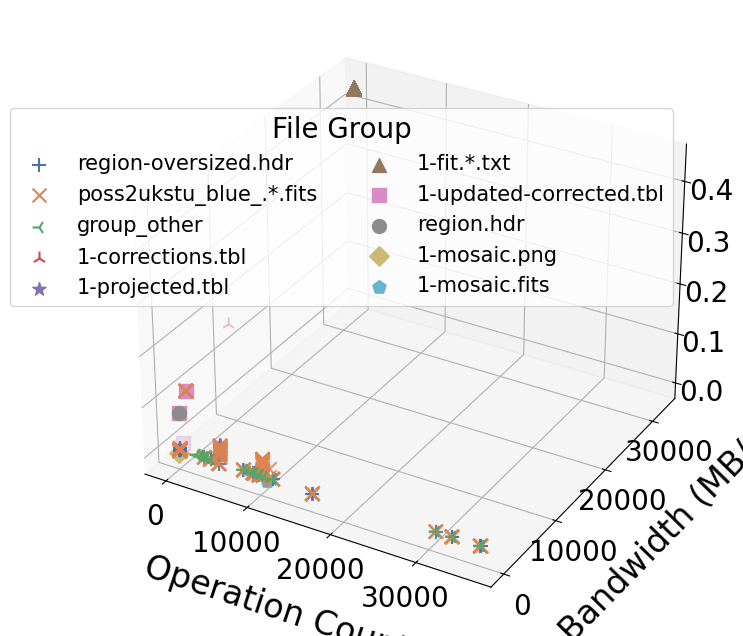

In [10]:

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Generate a color palette
unique_groups = df["file_group"].unique()
print(f"Unique groups [{len(unique_groups)}]: {unique_groups}")

num_groups = len(unique_groups)

# Define color palette and markers
palette = sns.color_palette("deep", num_groups)
markers = ['+', 'x', '3', '2', '*', '^', 's', 'o', 'D', 'p', 'h']

# Groups to exclude for 1000 genome
exclude_groups = ['AFR', 'EAS', 'SAS', 'ALL', 'EUR', 'GBR', 'AMR']
# Remove them from unique_groups
unique_groups = [g for g in unique_groups if g not in exclude_groups]

# Split file groups into groups of n
file_group_count = 20
group_batches = [unique_groups[i:i+file_group_count] for i in range(0, num_groups, file_group_count)]

for batch_idx, group_batch in enumerate(group_batches):
    # Skip empty groups
    valid_groups = [group for group in group_batch if group in df["file_group"].values]
    if not valid_groups:
        print(f"Skipping empty group {batch_idx+1}")
        continue

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Generate color and marker maps for current group
    color_map = {group: palette[i % len(palette)] for i, group in enumerate(valid_groups)}
    marker_map = {group: markers[i % len(markers)] for i, group in enumerate(valid_groups)}

    # Assign colors and markers
    df["color"] = df["file_group"].map(lambda group: color_map.get(group, 'black'))
    df["marker"] = df["file_group"].map(lambda group: marker_map.get(group, 'o'))

    # Iterate through the valid file groups
    for group in valid_groups:
        subset = df[df["file_group"] == group]
        if subset.empty:
            print(f"Skipping group '{group}' (no data)")
            continue

        ax.scatter(subset['opCount'], subset['trMiB'], subset['aggregateFilesizeMB'], 
                   label=group, 
                   color=color_map[group],  
                   marker=marker_map[group],  
                   s=100)
    # # After plotting all groups, set axis limits based on data
    # all_subset = df[df["file_group"].isin(valid_groups)]
    # ax.set_xlim(*padded_range(all_subset["trMiB"]))
    # ax.set_ylim(*padded_range(all_subset["stageOrder"]))
    # ax.set_zlim(*padded_range(all_subset["aggregateFilesizeMB"]))
    
    # Set font sizes
    plt.rc('font', size=20)
    plt.rc('axes', titlesize=24)
    plt.rc('axes', labelsize=24)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.rc('legend', fontsize=15)

    # Set axis labels
    ax.set_xlabel('Operation Count', labelpad=20)
    ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=20)
    ax.set_zlabel('Flow Size (MB)', labelpad=20)
    
    # Ensure y-axis only shows integers
    # ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    # ax.set_xlim(df['opCount'].max() * 1.1, 0)

    # Legend updated to reflect file groups
    ax.legend(title="File Group", loc="right", bbox_to_anchor=(0.55, 0.68, 0.4, 0.0),ncol=2)
    
    # plt.figure(constrained_layout=True)
    # Show and save figure
    fig.savefig(f'{result_path}/fileColor_group{batch_idx+1}_op_'+plot_file_name)
    plt.show()


In [21]:
manual_pairs = {
    ("initial_data", "mPro") : "1-1",
    ("initial_data", "mDiffF") : "1-1",
    ("initial_data", "mBgM") : "1-1",
    ("initial_data", "mBg") : "1-1",
    ("initial_data", "mImg") : "1-1",
    ("initial_data", "mAdd") : "1-1",
    
    
    ("mPro", "mDiffF") : "n-n",
    ("mDiffF", "mConF") : "n-1",
    ("mConF", "mBgM") : "1-1",
    ("mBgM", "mBg") : "n-1",
    ("mPro", "mBg") : "1-1",
    ("mBg", "mImg") : "1-1",
    ("mImg", "mAdd") : "1-1",
    ("mBg", "mAdd") : "n-1",
    ("mAdd", "mView") : "1-1",
    ("mView", "final_data") : "1-1",
}


# Split into read and write operations
df_reads = df[df['operation'] == 1].copy()
df_writes = df[df['operation'] == 0].copy()

# Aggregate metrics per task
read_metrics = df_reads.groupby('taskName').agg({
    'transferSize': 'sum',
    'aggregateFilesizeMB': 'sum',
    'totalTime': 'sum',
    'opCount': 'sum',
    'trMiB': 'mean',
    'stageOrder': 'first'
}).rename(columns=lambda x: x + '_read')

write_metrics = df_writes.groupby('taskName').agg({
    'transferSize': 'sum',
    'aggregateFilesizeMB': 'sum',
    'totalTime': 'sum',
    'opCount': 'sum',
    'trMiB': 'mean',
    'stageOrder': 'first'
}).rename(columns=lambda x: x + '_write')

# Combine based on your manual producer-consumer task pairs
rows = []
for producer, consumer in manual_pairs.keys():
    pc_label = producer + '→' + consumer

    if producer == "initial_data":
        if consumer not in read_metrics.index:
            print(f"Skipping special pair ({pc_label}): missing read data")
            continue
        read_row = read_metrics.loc[consumer]

        row = {
            'producerTask': producer,
            'consumerTask': consumer,
            'transferSize': read_row['transferSize_read'],
            'aggregateFilesizeMB': read_row['aggregateFilesizeMB_read'],
            'totalTime': read_row['totalTime_read'],
            'opCount': read_row['opCount_read'],
            'trMiB': read_row['trMiB_read'],
            'stageOrder_read': read_row['stageOrder_read'],
            'stageOrder_write': None,
            'pcPair': pc_label
        }
        rows.append(row)
        continue

    if consumer == "final_data":
        if producer not in write_metrics.index:
            print(f"Skipping special pair ({pc_label}): missing write data")
            continue
        write_row = write_metrics.loc[producer]

        row = {
            'producerTask': producer,
            'consumerTask': consumer,
            'transferSize': write_row['transferSize_write'],
            'aggregateFilesizeMB': write_row['aggregateFilesizeMB_write'],
            'totalTime': write_row['totalTime_write'],
            'opCount': write_row['opCount_write'],
            'trMiB': write_row['trMiB_write'],
            'stageOrder_read': None,
            'stageOrder_write': write_row['stageOrder_write'],
            'pcPair': pc_label
        }
        rows.append(row)
        continue

    # Regular handling
    if producer not in write_metrics.index or consumer not in read_metrics.index:
        print(f"Skipping pair ({pc_label}): missing data")
        continue

    write_row = write_metrics.loc[producer]
    read_row = read_metrics.loc[consumer]

    row = {
        'producerTask': producer,
        'consumerTask': consumer,
        'transferSize': read_row['transferSize_read'] + write_row['transferSize_write'],
        'aggregateFilesizeMB': read_row['aggregateFilesizeMB_read'] + write_row['aggregateFilesizeMB_write'],
        'totalTime': read_row['totalTime_read'] + write_row['totalTime_write'],
        'opCount': read_row['opCount_read'] + write_row['opCount_write'],
        'trMiB': (read_row['trMiB_read'] + write_row['trMiB_write']) / 2,
        'stageOrder_read': read_row['stageOrder_read'],
        'stageOrder_write': write_row['stageOrder_write'],
        'pcPair': pc_label
    }

    rows.append(row)

# Create DataFrame
df_pc = pd.DataFrame(rows)

# Show summary
print(f"Constructed producer-consumer DataFrame with {len(df_pc)} pairs.")
print(df_pc[['pcPair', 'aggregateFilesizeMB', 'totalTime', 'trMiB']].head())

# Optional: create pair label
df_pc['pcPair'] = df_pc['producerTask'] + '→' + df_pc['consumerTask']

# Get unique producer-consumer pairs
unique_pairs = df_pc['pcPair'].unique()
if len(unique_pairs) == 0:
    print("No producer-consumer pairs available for plotting.")
    exit()

print(unique_pairs)


Skipping special pair (initial_data→mBgM): missing read data
Skipping pair (mConF→mBgM): missing data
Skipping pair (mAdd→mView): missing data
Constructed producer-consumer DataFrame with 13 pairs.
                pcPair  aggregateFilesizeMB  totalTime        trMiB
0    initial_data→mPro             0.351973   3.515419     0.164413
1  initial_data→mDiffF             3.984848   4.280497    65.313664
2     initial_data→mBg             2.040890   1.226775     4.673740
3    initial_data→mImg             1.873707   0.001293  1449.131559
4    initial_data→mAdd             0.155565   0.000892   174.449411
['initial_data→mPro' 'initial_data→mDiffF' 'initial_data→mBg'
 'initial_data→mImg' 'initial_data→mAdd' 'mPro→mDiffF' 'mDiffF→mConF'
 'mBgM→mBg' 'mPro→mBg' 'mBg→mImg' 'mImg→mAdd' 'mBg→mAdd'
 'mView→final_data']


In [22]:
print("=== aggregateFilesizeMB Range ===")
print(f"df_pc: min = {df_pc['aggregateFilesizeMB'].min():.2f}, max = {df_pc['aggregateFilesizeMB'].max():.2f}")
print(f"df   : min = {df['aggregateFilesizeMB'].min():.2f}, max = {df['aggregateFilesizeMB'].max():.2f}")


=== aggregateFilesizeMB Range ===
df_pc: min = 0.00, max = 53.33
df   : min = 0.00, max = 0.44


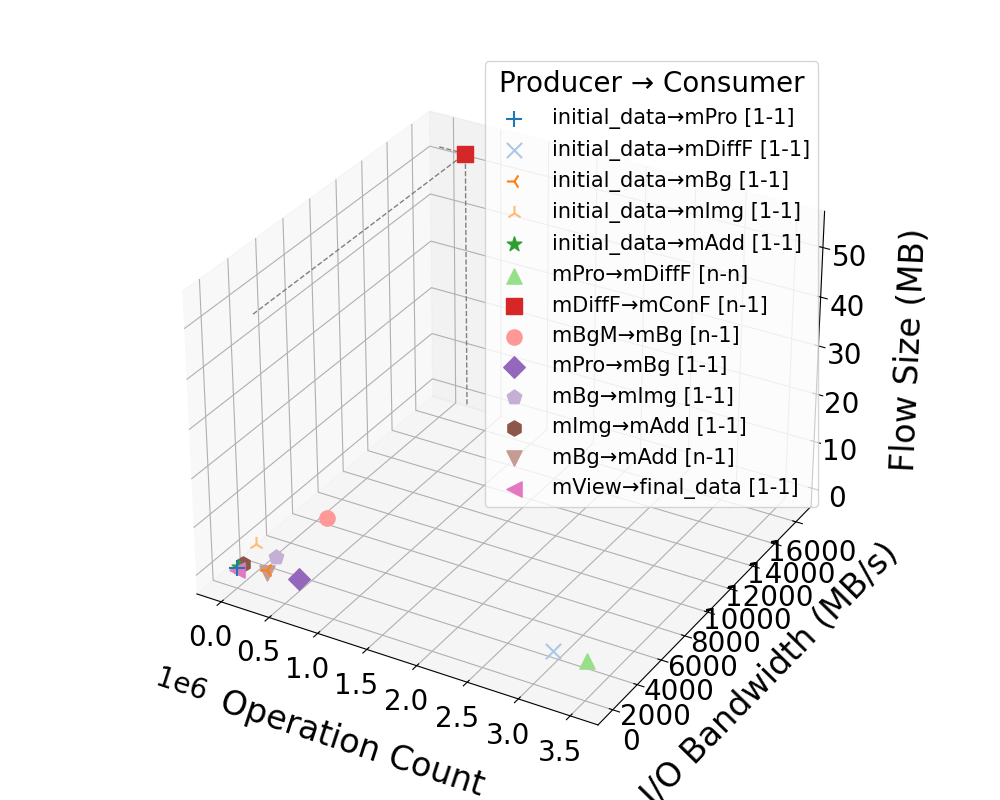

In [23]:

# Plot settings
palette = sns.color_palette("tab20", len(unique_pairs))
markers = ['+', 'x', '3', '2', '*', '^', 's', 'o', 'D', 'p', 'h', 'v', '<', '>', '|']
pair_group_count = 15
pair_groups = [unique_pairs[i:i+pair_group_count] for i in range(0, len(unique_pairs), pair_group_count)]

for group_idx, pair_group in enumerate(pair_groups):
    subset_group = df_pc[df_pc['pcPair'].isin(pair_group)]
    if subset_group.empty:
        print(f"Skipping empty group {group_idx+1}")
        continue

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Assign colors and markers
    color_map = {pair: palette[i % len(palette)] for i, pair in enumerate(pair_group)}
    marker_map = {pair: markers[i % len(markers)] for i, pair in enumerate(pair_group)}

    seen_labels = set()  # Track labels we've already added

    for _, row in subset_group.iterrows():
        pair_label = row['pcPair']
        producer, consumer = pair_label.split('→')
        short_producer = shorten_task_name(producer)
        short_consumer = shorten_task_name(consumer)

        # Fetch pattern from manual_pairs
        pattern = manual_pairs.get((producer, consumer), "unknown")
        short_label = f"{short_producer}→{short_consumer} [{pattern}]"

        show_label = pair_label not in seen_labels
        seen_labels.add(pair_label)

        trMiB = row['trMiB'] if pd.notna(row['trMiB']) else 0
        opCount = row['opCount'] if pd.notna(row['opCount']) else 0
        filesize = row['aggregateFilesizeMB'] if pd.notna(row['aggregateFilesizeMB']) else 0

        ax.scatter(
            opCount, trMiB, filesize,
            label=short_label if show_label else None,
            color=color_map[pair_label],
            marker=marker_map[pair_label],
            s=120
        )
        if "mDiffF" in producer:
            ax.plot([opCount, opCount], [trMiB, trMiB], [0, filesize], linestyle='dashed', color='gray', linewidth=1)
            ax.plot([opCount, opCount], [0, trMiB], [filesize, filesize], linestyle='dashed', color='gray', linewidth=1)
            ax.plot([0, opCount], [trMiB, trMiB], [filesize, filesize], linestyle='dashed', color='gray', linewidth=1)

    # Set font sizes
    plt.rc('font', size=20)
    plt.rc('axes', titlesize=24)
    plt.rc('axes', labelsize=24)
    plt.rc('xtick', labelsize=20)
    plt.rc('ytick', labelsize=20)
    plt.rc('legend', fontsize=15)

    # Set axis labels
    ax.set_xlabel('Operation Count', labelpad=23)
    ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=20)
    ax.set_zlabel('Flow Size (MB)', labelpad=20)
    
    # Ensure y-axis only shows integers
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    # ax.view_init(elev=25, azim=135)
    # # Flip x-axis from right to left
    # ymax = subset_group['trMiB'].max() * 1.1
    # ax.set_ylim(ymax, 0)

    # Legend updated to reflect file groups
    ax.legend(title="Producer → Consumer", loc="right", bbox_to_anchor=(0.16, 0.68, 0.8, 0.0))

    plt.tight_layout()
    plt.show()
    fig.savefig(f'{result_path}/pcAgg_group{group_idx+1}_{plot_file_name}')

In [24]:
print(df[['operation', 'taskName', 'prevTask', 'fileName']].head(20))

    operation taskName      prevTask                            fileName
0           1     mPro  initial_data                region-oversized.hdr
1           1     mPro  initial_data        poss2ukstu_blue_003_004.fits
2           0     mPro           NaN       pposs2ukstu_blue_003_004.fits
3           0     mPro           NaN  pposs2ukstu_blue_003_004_area.fits
4           0     mPro           NaN  pposs2ukstu_blue_003_002_area.fits
5           1     mPro  initial_data                region-oversized.hdr
6           1     mPro  initial_data        poss2ukstu_blue_003_002.fits
7           0     mPro           NaN       pposs2ukstu_blue_003_002.fits
8           1     mPro  initial_data                region-oversized.hdr
9           1     mPro  initial_data        poss2ukstu_blue_004_003.fits
10          0     mPro           NaN  pposs2ukstu_blue_004_003_area.fits
11          0     mPro           NaN       pposs2ukstu_blue_004_003.fits
12          1     mPro  initial_data        poss2uk

In [15]:
print(unique_groups)

['region-oversized.hdr', 'poss2ukstu_blue_.*.fits', 'group_other', '1-corrections.tbl', '1-projected.tbl', '1-fit.*.txt', '1-updated-corrected.tbl', 'region.hdr', '1-mosaic.png', '1-mosaic.fits']


/tmp/ipykernel_1439218/1186687784.py:45: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, wspace=0.4)


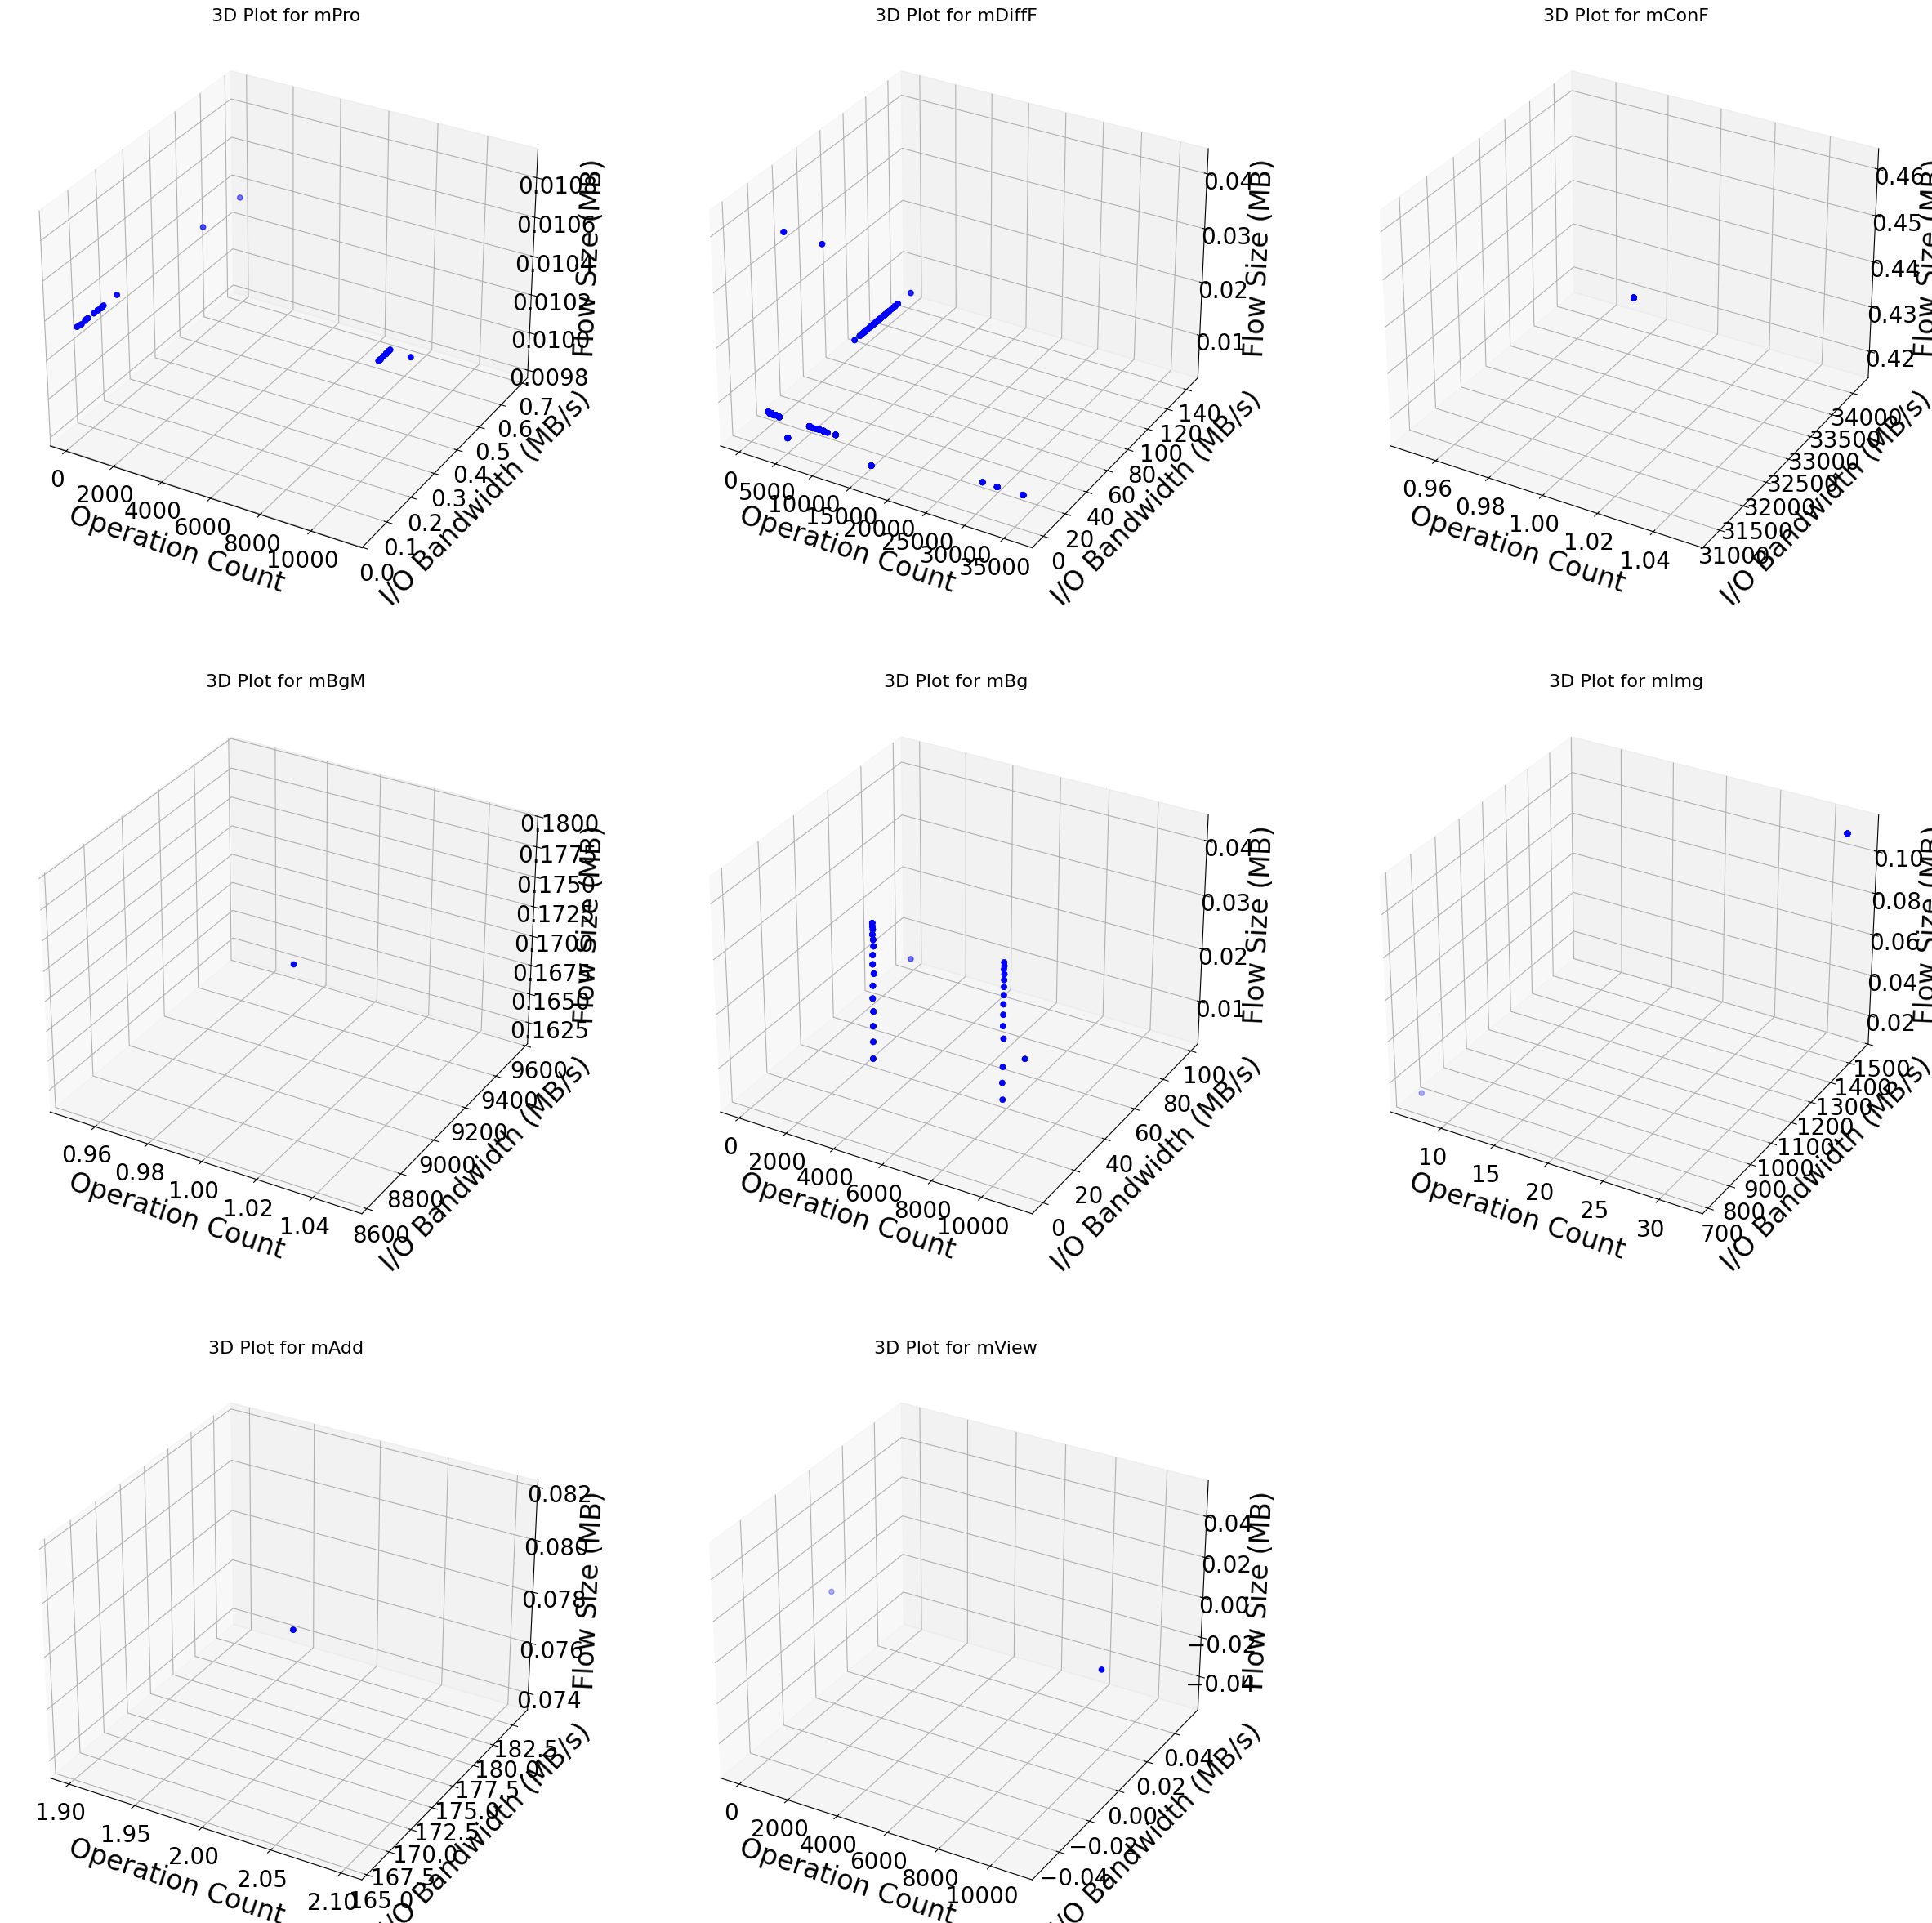

<Figure size 640x480 with 0 Axes>

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

x = df['trMiB']
y = df['opCount']
z = df['aggregateFilesizeMB']

# Generate a color palette
unique_tasks = df['taskName'].unique()
num_tasks = len(unique_tasks)

# Set the font sizes for various plot elements
plt.rc('font', size=18)             # Default text size
plt.rc('axes', titlesize=16)        # Axes title font size
plt.rc('axes', labelsize=24)        # Axes label font size
plt.rc('xtick', labelsize=20)       # X-tick label font size
plt.rc('ytick', labelsize=20)       # Y-tick label font size
plt.rc('legend', fontsize=16)       # Legend font size

# Determine the grid layout based on the number of tasks
num_cols = min(3, num_tasks)  # Max 3 columns per row
num_rows = int(np.ceil(num_tasks / num_cols))  # Calculate required rows

# Create a figure and define the GridSpec
fig = plt.figure(figsize=(num_cols * 10, num_rows * 10))
gs = gridspec.GridSpec(num_rows, num_cols)

# Generate grid positions dynamically
task_indices = [(i // num_cols, i % num_cols) for i in range(num_tasks)]

for i, (task, (row, col)) in enumerate(zip(unique_tasks, task_indices)):
    subset = df[df['taskName'] == task]
    ax = fig.add_subplot(gs[row, col], projection='3d')
    ax.scatter(subset['opCount'], subset['trMiB'], subset['aggregateFilesizeMB'], 
               label=shorten_task_name(task), 
               color='b')
    ax.set_title(f'3D Plot for {task}')
    ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=10)
    ax.set_xlabel('Operation Count', labelpad=13)
    ax.set_zlabel('Flow Size (MB)', labelpad=10)

plt.figure(constrained_layout=True)
plt.subplots_adjust(hspace=0.4, wspace=0.4) 
plt.show()
fig.savefig(f'{result_path}/tasksubplot_' + plot_file_name)

/tmp/ipykernel_1439218/1860292298.py:41: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, wspace=0.4)


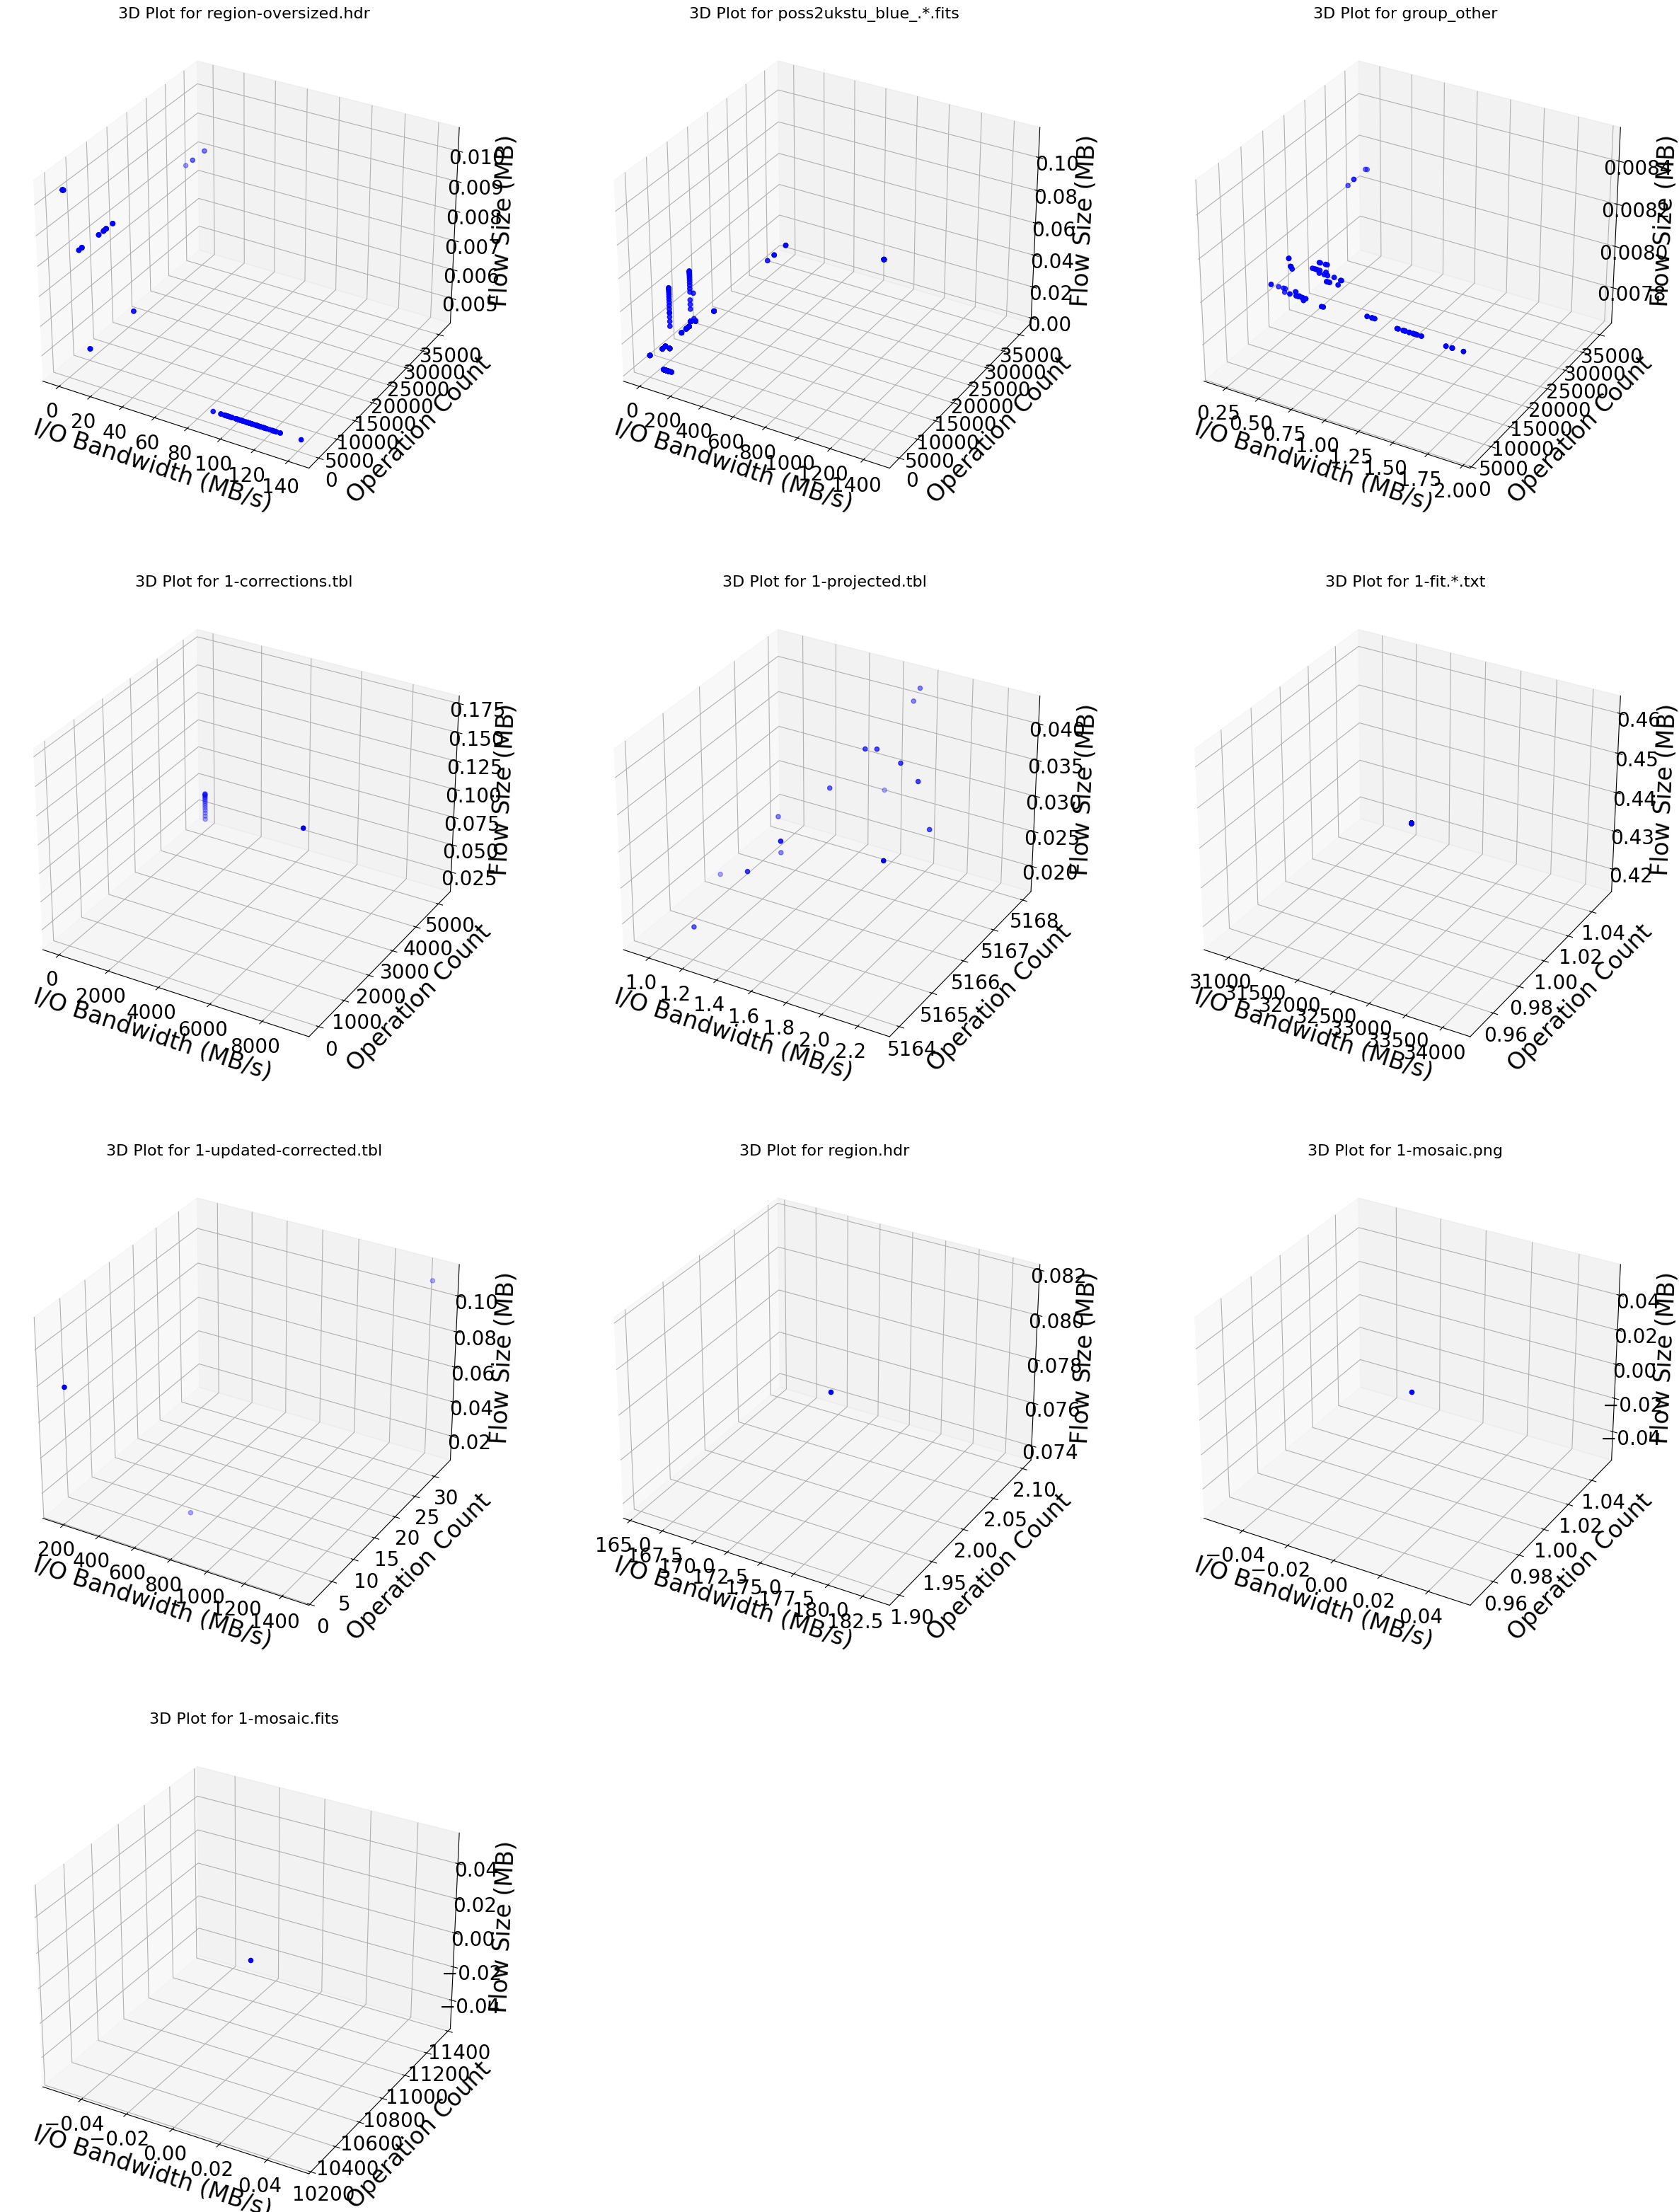

<Figure size 640x480 with 0 Axes>

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Generate a color palette
unique_filegroup = df['file_group'].unique()
num_filegroups = len(unique_filegroup)

# Set the font sizes for various plot elements
plt.rc('font', size=18)             # Default text size
plt.rc('axes', titlesize=16)        # Axes title font size
plt.rc('axes', labelsize=24)        # Axes label font size
plt.rc('xtick', labelsize=20)       # X-tick label font size
plt.rc('ytick', labelsize=20)       # Y-tick label font size
plt.rc('legend', fontsize=16)       # Legend font size

# Determine the grid layout based on the number of unique file groups
num_cols = min(3, num_filegroups)  # Max 3 columns per row
num_rows = int(np.ceil(num_filegroups / num_cols))  # Calculate required rows

# Create a figure and define the GridSpec
fig = plt.figure(figsize=(num_cols * 10, num_rows * 10))
gs = gridspec.GridSpec(num_rows, num_cols)

# Generate grid positions dynamically
task_indices = [(i // num_cols, i % num_cols) for i in range(num_filegroups)]

for i, (file, (row, col)) in enumerate(zip(unique_filegroup, task_indices)):
    subset = df[df['file_group'] == file]
    ax = fig.add_subplot(gs[row, col], projection='3d')
    ax.scatter(subset['trMiB'], subset['opCount'], subset['aggregateFilesizeMB'], 
               label=file, 
               color='b')
    ax.set_title(f'3D Plot for {file}')
    ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=10)
    ax.set_ylabel('Operation Count', labelpad=13)
    ax.set_zlabel('Flow Size (MB)', labelpad=10)

plt.figure(constrained_layout=True)
plt.subplots_adjust(hspace=0.4, wspace=0.4) 
plt.show()
fig.savefig(f'{result_path}/filegroup_subplot_op_' + plot_file_name)

/tmp/ipykernel_1439218/4260203375.py:42: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, wspace=0.4)


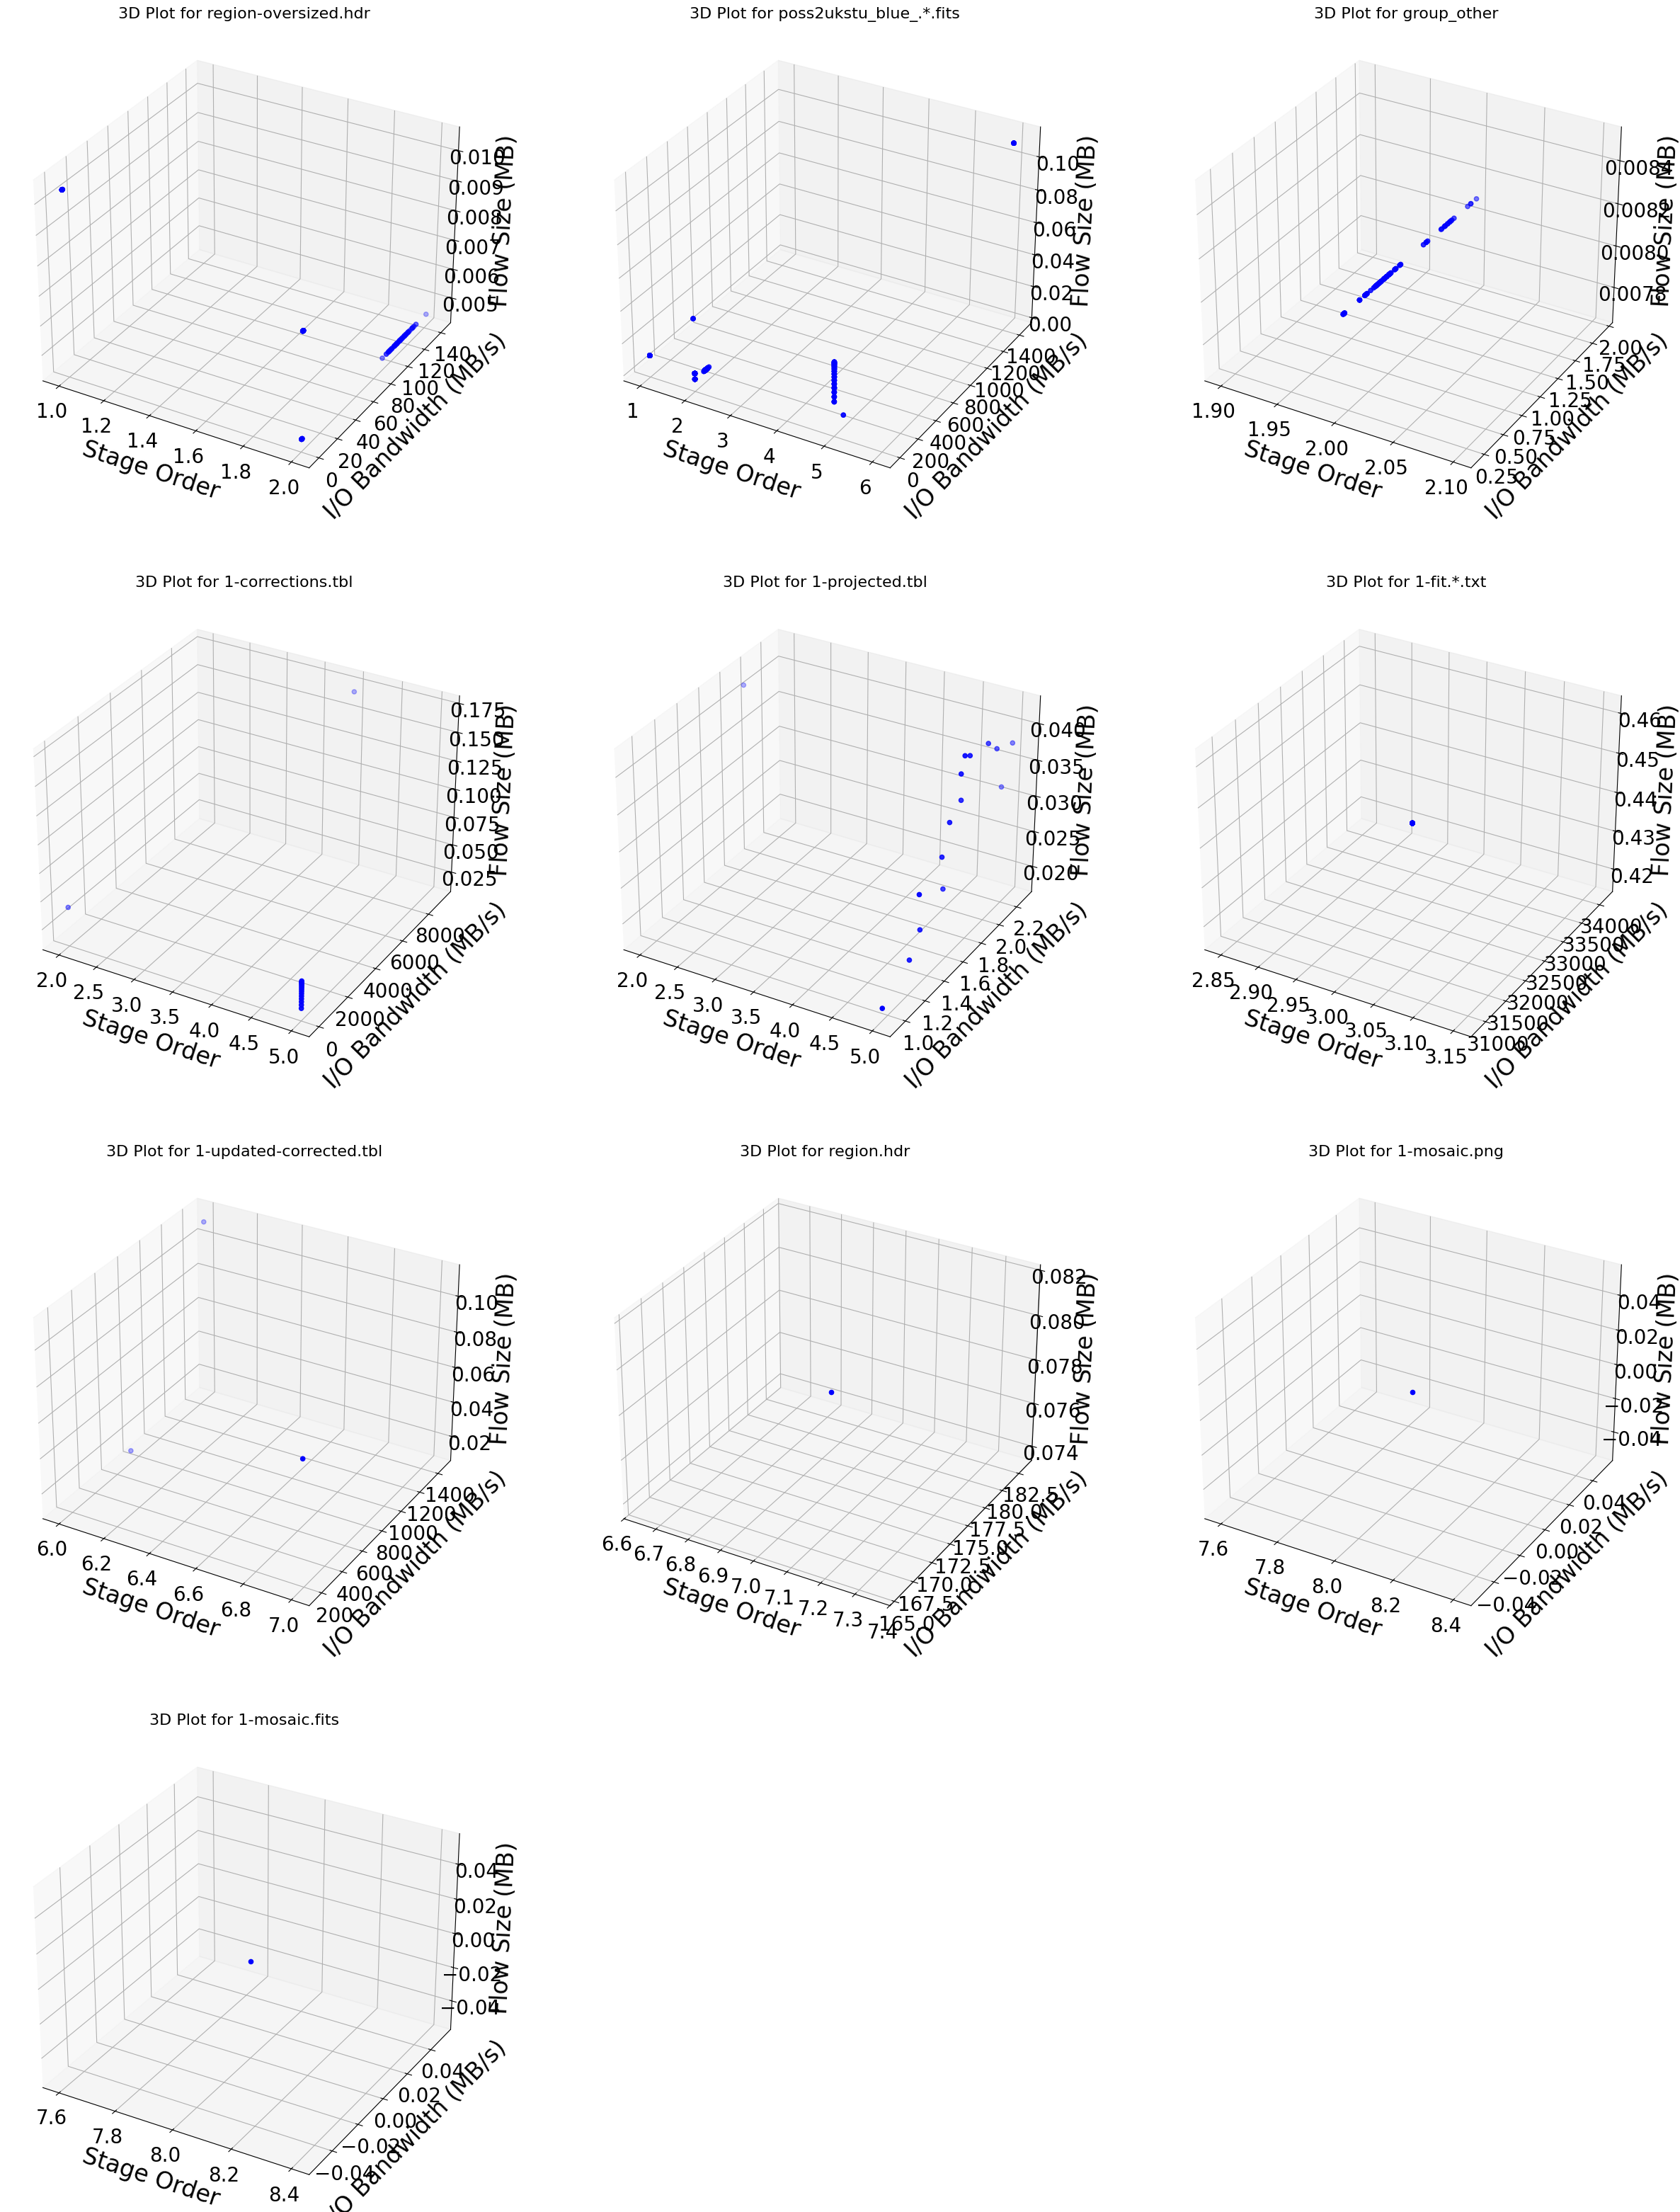

<Figure size 640x480 with 0 Axes>

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


# Generate a color palette
unique_filegroup = df['file_group'].unique()
num_filegroups = len(unique_filegroup)

# Set the font sizes for various plot elements
plt.rc('font', size=18)             # Default text size
plt.rc('axes', titlesize=16)        # Axes title font size
plt.rc('axes', labelsize=24)        # Axes label font size
plt.rc('xtick', labelsize=20)       # X-tick label font size
plt.rc('ytick', labelsize=20)       # Y-tick label font size
plt.rc('legend', fontsize=16)       # Legend font size

# Determine the grid layout based on the number of unique file groups
num_cols = min(3, num_filegroups)  # Max 3 columns per row
num_rows = int(np.ceil(num_filegroups / num_cols))  # Calculate required rows

# Create a figure and define the GridSpec
fig = plt.figure(figsize=(num_cols * 10, num_rows * 10))
gs = gridspec.GridSpec(num_rows, num_cols)

# Generate grid positions dynamically
task_indices = [(i // num_cols, i % num_cols) for i in range(num_filegroups)]

for i, (file, (row, col)) in enumerate(zip(unique_filegroup, task_indices)):
    subset = df[df['file_group'] == file]
    ax = fig.add_subplot(gs[row, col], projection='3d')
    ax.scatter(subset['stageOrder'], subset['trMiB'], subset['aggregateFilesizeMB'], 
               label=file, 
               color='b')
    ax.set_title(f'3D Plot for {file}')
    ax.set_ylabel('I/O Bandwidth (MB/s)', labelpad=10)
    ax.set_xlabel('Stage Order', labelpad=13)
    ax.set_zlabel('Flow Size (MB)', labelpad=10)

plt.figure(constrained_layout=True)
plt.subplots_adjust(hspace=0.4, wspace=0.4) 
plt.show()
fig.savefig(f'{result_path}/filegroup_subplot_stage_' + plot_file_name)

In [19]:
df.columns, df['stageOrder'].unique()

(Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
        'numTasks', 'parallelism', 'totalTime', 'numNodesList', 'numNodes',
        'tasksPerNode', 'trMiB', 'storageType', 'opCount', 'taskName',
        'taskPID', 'fileName', 'stageOrder', 'prevTask',
        'estimated_trMiB_ssd_p', 'estimated_trMiB_beegfs_p',
        'estimated_trMiB_ssd_16p', 'estimated_ts_slope_ssd_16p',
        'estimated_trMiB_beegfs_16p', 'estimated_ts_slope_beegfs_16p',
        'estimated_trMiB_ssd_1p', 'estimated_ts_slope_ssd_1p',
        'estimated_trMiB_beegfs_1p', 'estimated_ts_slope_beegfs_1p', 'io_type',
        'color', 'marker', 'file_group'],
       dtype='object'),
 array([1, 2, 3, 4, 5, 6, 7, 8]))